# Projeto Big Mart Sales - Previsão de Vendas
Este projeto tem como objetivo construir um modelo de Machine Learning capaz de prever as vendas de produtos em diferentes filiais da rede Big Mart.

## 1. Carregamento e Exploração Inicial dos Dados
Abaixo, faremos a importação da biblioteca `pandas` e o carregamento dos conjuntos de dados de treino e teste.

In [1]:
import pandas as pd

In [2]:
# Carregando os arquivos de dados
treino = pd.read_csv('Train-Set.csv')
teste = pd.read_csv('Test-Set.csv')

In [4]:
# Exibindo o tamanho das tabelas e as primeiras 5 linhas do treino
print(f"Tamanho do treino: {treino.shape}")
print(f"Tamanho do teste: {teste.shape}")
treino.head()

Tamanho do treino: (8523, 12)
Tamanho do teste: (5681, 11)


,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 2. Análise de Consistência e Limpeza de Dados

Nesta etapa, vamos verificar a consistência das variáveis categóricas. Foi identificado que a coluna `FatContent` possui registros duplicados devido a erros de digitação (ex: 'low fat' e 'LF' em vez de 'Low Fat'). 

Abaixo, vamos visualizar esses valores únicos e aplicar a correção tanto no conjunto de treino quanto no de teste.

In [5]:
# Verificando os valores errados na coluna FatContent
print("Valores antes da correção no Treino:")
print(treino['FatContent'].value_counts())

Valores antes da correção no Treino:
FatContent
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


In [6]:
# Corrigindo os erros de digitação substituindo os termos errados pelos corretos
dicionario_correcao = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}

treino['FatContent'] = treino['FatContent'].replace(dicionario_correcao)
teste['FatContent'] = teste['FatContent'].replace(dicionario_correcao)

# Verificando se a correção funcionou
print("Valores após a correção no Treino:")
print(treino['FatContent'].value_counts())

Valores após a correção no Treino:
FatContent
Low Fat    5517
Regular    3006
Name: count, dtype: int64


## 3. Tratamento de Valores Ausentes (Missing Values)

Para que o modelo de Machine Learning funcione, precisamos de tratar as colunas com valores nulos utilizando regras lógicas:
1. **`Weight` (Peso):** O mesmo produto (`ProductID`) é vendido em lojas diferentes. Se o peso está em falta numa loja, podemos preenchê-lo com a média de peso desse mesmo produto nas outras lojas. Caso o produto não tenha histórico nenhum, usamos a média geral.
2. **`OutletSize` (Tamanho da Loja):** Lojas do mesmo tipo (`OutletType`) tendem a ter tamanhos parecidos. Vamos preencher os tamanhos vazios usando a 'Moda' (o valor mais frequente) para cada tipo específico de loja.
   

In [7]:
# Criar um mapeamento com a média de peso para cada ID de produto
item_avg_weight = treino.groupby('ProductID')['Weight'].mean()

# Função para preencher o peso nulo usando o ID do produto ou a média global
def preencher_peso(row):
    if pd.isnull(row['Weight']):
        # Se houver média para este ID, usa-a. Se não, usa a média geral de toda a base.
        return item_avg_weight.get(row['ProductID'], treino['Weight'].mean())
    return row['Weight']

# Aplicar a função tanto no conjunto de treino como no de teste
treino['Weight'] = treino.apply(preencher_peso, axis=1)
teste['Weight'] = teste.apply(preencher_peso, axis=1)

# Verificar se ainda restou algum valor nulo em Weight
print("Valores nulos em 'Weight' após a correção (Treino):", treino['Weight'].isnull().sum())

Valores nulos em 'Weight' após a correção (Treino): 4


In [8]:
# Preenchendo os 4 produtos restantes com a média geral de pesos da base
peso_medio_global = treino['Weight'].mean()

treino['Weight'] = treino['Weight'].fillna(peso_medio_global)
teste['Weight'] = teste['Weight'].fillna(peso_medio_global)

# Verificando novamente
print("Valores nulos finais em 'Weight' (Treino):", treino['Weight'].isnull().sum())
print("Valores nulos finais em 'Weight' (Teste):", teste['Weight'].isnull().sum())

Valores nulos finais em 'Weight' (Treino): 0
Valores nulos finais em 'Weight' (Teste): 0


In [9]:
# Determinar a moda (valor mais frequente) de OutletSize para cada OutletType
# Usamos uma tabela dinâmica (pivot_table) para mapear isto
outlet_size_mode = treino.pivot_table(values='OutletSize', columns='OutletType', aggfunc=lambda x: x.mode().iat[0])

# Função para preencher o tamanho nulo com base no tipo da loja
def preencher_tamanho(row):
    if pd.isnull(row['OutletSize']):
        return outlet_size_mode[row['OutletType']]
    return row['OutletSize']

# Aplicar no treino e no teste
treino['OutletSize'] = treino.apply(preencher_tamanho, axis=1)
teste['OutletSize'] = teste.apply(preencher_tamanho, axis=1)

# Verificar se ainda restou algum valor nulo em OutletSize
print("Valores nulos em 'OutletSize' após a correção (Treino):", treino['OutletSize'].isnull().sum())

Valores nulos em 'OutletSize' após a correção (Treino): 0


## 4. Correção da Visibilidade do Produto (Valores Zero Ocultos)

A variável `ProductVisibility` possui diversos valores iguais a 0. No entanto, se um produto está registado e a ser vendido numa loja, ele precisa de ter alguma visibilidade mínima na prateleira. 

Portanto, trataremos os valores iguais a 0 como dados ausentes e iremos substituí-los pela visibilidade média daquele produto específico (`ProductID`) ao longo de todas as outras lojas.


In [10]:
import numpy as np

# Substituir temporariamente os zeros por NaN para não afetarem o cálculo da média
treino['ProductVisibility'] = treino['ProductVisibility'].replace(0, np.nan)
teste['ProductVisibility'] = teste['ProductVisibility'].replace(0, np.nan)

# Calcular a média de visibilidade para cada ID de produto
visibility_avg = treino.groupby('ProductID')['ProductVisibility'].mean()

# Função para preencher a visibilidade nula com a média do produto ou a média global
def preencher_visibilidade(row):
    if pd.isnull(row['ProductVisibility']):
        return visibility_avg.get(row['ProductID'], treino['ProductVisibility'].mean())
    return row['ProductVisibility']

# Aplicar a correção no treino e no teste
treino['ProductVisibility'] = treino.apply(preencher_visibilidade, axis=1)
teste['ProductVisibility'] = teste.apply(preencher_visibilidade, axis=1)

# Verificar se ainda sobrou algum valor igual a zero
print("Quantidade de valores zero em 'ProductVisibility' (Treino):", (treino['ProductVisibility'] == 0).sum())
print("Quantidade de valores zero em 'ProductVisibility' (Teste):", (teste['ProductVisibility'] == 0).sum())

Quantidade de valores zero em 'ProductVisibility' (Treino): 0
Quantidade de valores zero em 'ProductVisibility' (Teste): 0


## 5. Engenharia de Recursos (Feature Engineering): Idade da Loja

A coluna `EstablishmentYear` indica o ano em que a loja foi criada. Para o modelo de Machine Learning, o número do ano isolado é menos informativo do que o **tempo de existência** do estabelecimento. 

Abaixo, criaremos uma nova variável chamada `Outlet_Age` que representa a idade da loja (calculada com base no ano final do histórico dos dados, 2013), permitindo ao modelo entender o impacto da maturidade da loja nas vendas.

In [11]:
# Criando a variável 'Idade da Loja' com base no ano de referência dos dados (2013)
treino['Outlet_Age'] = 2013 - treino['EstablishmentYear']
teste['Outlet_Age'] = 2013 - teste['EstablishmentYear']

# Visualizando como ficou a nova coluna junto com o ano original
treino[['EstablishmentYear', 'Outlet_Age']].head()

,EstablishmentYear,Outlet_Age
0,1999,14
1,2009,4
2,1999,14
3,1998,15
4,1987,26


## 6. Codificação de Variáveis Categóricas (Encoding)

Os modelos de Machine Learning exigem entradas numéricas para realizar os cálculos matemáticos. Nesta etapa, transformaremos as variáveis de texto em números:
1. **Ordinal Encoding:** Aplicado na coluna `OutletSize` e `LocationType`, pois possuem uma ordem de grandeza lógica.
2. **One-Hot Encoding (Variáveis Dummy):** Aplicado nas demais colunas categóricas (`FatContent`, `ProductType`, `OutletType`) para criar colunas binárias (0 ou 1) sem impor uma ordem hierárquica falsa.

In [12]:
import pandas as pd
import numpy as np

# 1. Recarregar os dados do zero para limpar erros da memória
treino = pd.read_csv('Train-Set.csv')
teste = pd.read_csv('Test-Set.csv')

# 2. Corrigir os erros de digitação do FatContent
dicionario_correcao = {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}
treino['FatContent'] = treino['FatContent'].replace(dicionario_correcao)
teste['FatContent'] = teste['FatContent'].replace(dicionario_correcao)

# 3. Tratar Valores Ausentes do Peso (Weight)
item_avg_weight = treino.groupby('ProductID')['Weight'].mean()
def preencher_peso(row):
    if pd.isnull(row['Weight']):
        return item_avg_weight.get(row['ProductID'], treino['Weight'].mean())
    return row['Weight']

treino['Weight'] = treino.apply(preencher_peso, axis=1)
teste['Weight'] = teste.apply(preencher_peso, axis=1)

# Garantir que nenhum peso isolado fique nulo
peso_medio_global = treino['Weight'].mean()
treino['Weight'] = treino['Weight'].fillna(peso_medio_global)
teste['Weight'] = teste['Weight'].fillna(peso_medio_global)

# 4. Tratar Valores Ausentes do Tamanho da Loja (OutletSize)
# Encontrando o tamanho mais frequente (moda) para cada tipo de loja de forma textual pura
outlet_size_mode = treino.dropna(subset=['OutletSize']).groupby('OutletType')['OutletSize'].agg(lambda x: x.mode().iloc[0])

def preencher_tamanho(row):
    if pd.isnull(row['OutletSize']):
        return outlet_size_mode[row['OutletType']]
    return row['OutletSize']

treino['OutletSize'] = treino.apply(preencher_tamanho, axis=1)
teste['OutletSize'] = teste.apply(preencher_tamanho, axis=1)

# 5. Corrigir a Visibilidade igual a Zero (Valores Ocultos)
treino['ProductVisibility'] = treino['ProductVisibility'].replace(0, np.nan)
teste['ProductVisibility'] = teste['ProductVisibility'].replace(0, np.nan)
visibility_avg = treino.groupby('ProductID')['ProductVisibility'].mean()

def preencher_visibilidade(row):
    if pd.isnull(row['ProductVisibility']):
        return visibility_avg.get(row['ProductID'], treino['ProductVisibility'].mean())
    return row['ProductVisibility']

treino['ProductVisibility'] = treino.apply(preencher_visibilidade, axis=1)
teste['ProductVisibility'] = teste.apply(preencher_visibilidade, axis=1)

# 6. Engenharia de Recursos: Idade da Loja
treino['Outlet_Age'] = 2013 - treino['EstablishmentYear']
teste['Outlet_Age'] = 2013 - teste['EstablishmentYear']

# 7. ENCODING (Transformar os textos em números)
mapeamento_tamanho = {'Small': 0, 'Medium': 1, 'High': 2}
mapeamento_localizacao = {'Tier 1': 0, 'Tier 2': 1, 'Tier 2 ': 1, 'Tier 3': 2} # Prevenindo espaços extras

treino['OutletSize'] = treino['OutletSize'].map(mapeamento_tamanho)
teste['OutletSize'] = teste['OutletSize'].map(mapeamento_tamanho)

# Garantir que a localização converta limpando espaços em branco antes
treino['LocationType'] = treino['LocationType'].str.strip().map(mapeamento_localizacao)
teste['LocationType'] = teste['LocationType'].str.strip().map(mapeamento_localizacao)

# One-Hot Encoding para as colunas sem ordem
colunas_dummy = ['FatContent', 'ProductType', 'OutletType']
treino_final = pd.get_dummies(treino, columns=colunas_dummy, drop_first=True)
teste_final = pd.get_dummies(teste, columns=colunas_dummy, drop_first=True)

# Separar os dados para o Modelo de IA
colunas_remover = ['ProductID', 'OutletID', 'EstablishmentYear']
X_treino = treino_final.drop(columns=['OutletSales'] + colunas_remover)
y_treino = treino_final['OutletSales']
X_teste = teste_final.drop(columns=colunas_remover)

# Alinhar colunas do treino e teste
X_treino, X_teste = X_treino.align(X_teste, join='left', axis=1, fill_value=0)

# Converter colunas booleanas True/False do get_dummies em números 1 e 0
X_treino = X_treino.astype(float)
X_teste = X_teste.astype(float)

# Imprimir o resultado final na tela
print("--- SUCESSO TOTAL! ---")
print("Tamanho final da tabela de treino (X_treino):", X_treino.shape)
print("Tamanho final da tabela de teste (X_teste):", X_teste.shape)

--- SUCESSO TOTAL! ---
Tamanho final da tabela de treino (X_treino): (8523, 25)
Tamanho final da tabela de teste (X_teste): (5681, 25)


## 7. Análise Exploratória de Dados (EDA) - Mapeamento de Correlações

Para extrair inteligência dos dados estruturados antes da modelagem matemática, analisaremos as correlações lineares entre as variáveis numéricas e o nosso alvo de previsão (`OutletSales`). 

Utilizaremos um Mapa de Calor (Heatmap) para identificar quais propriedades dos produtos ou características das filiais desempenham um papel crucial no aumento das vendas, além de um gráfico de dispersão para mapear o comportamento de consumo em relação ao preço dos produtos (MRP).

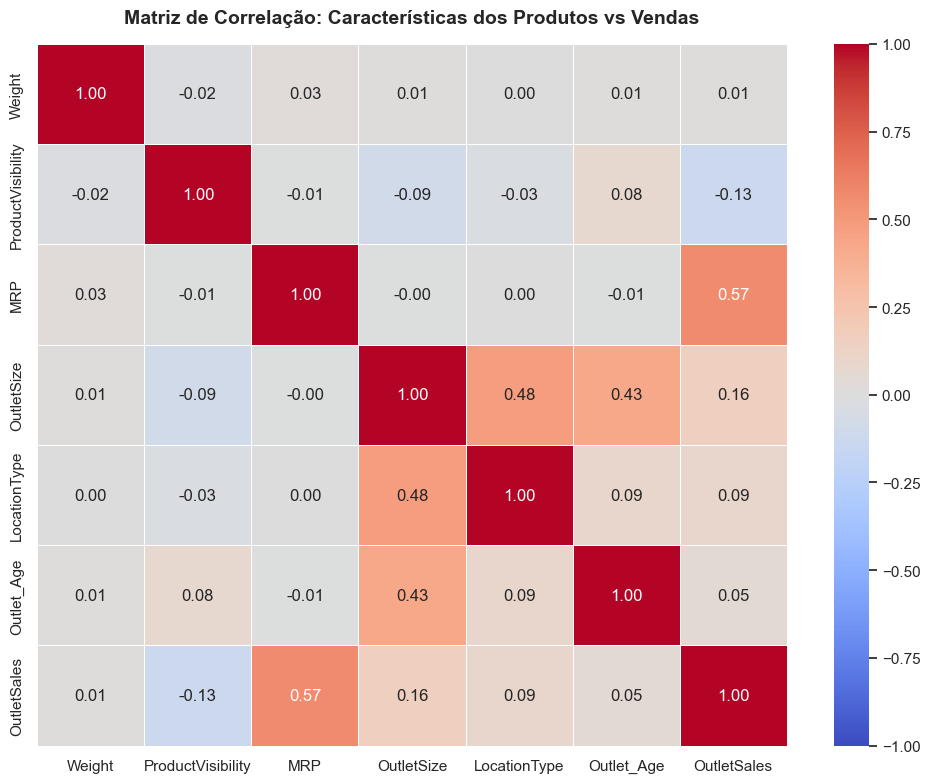

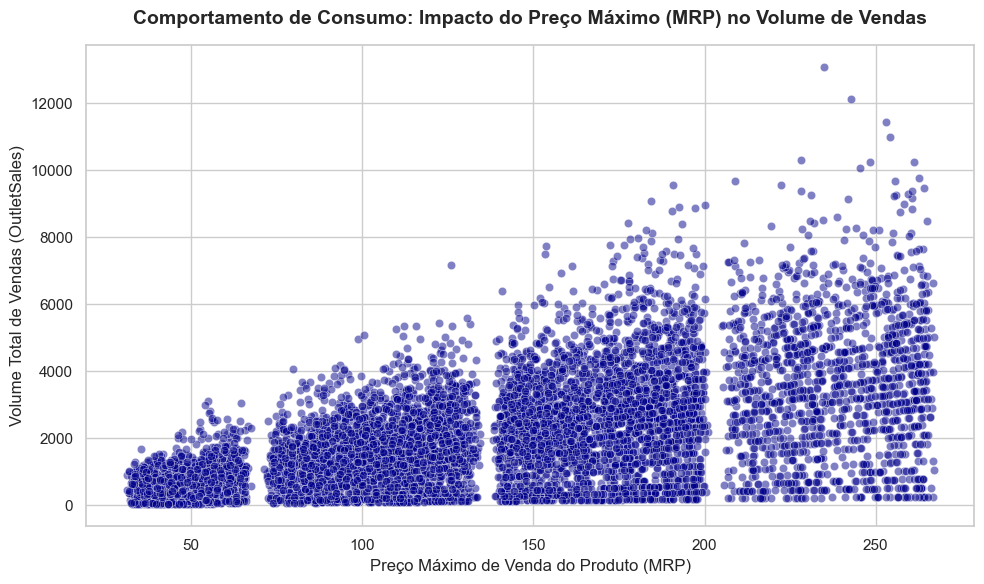

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Criando um DataFrame temporário unindo os previsores e o alvo para calcular a correlação
df_eda = X_treino.copy()
df_eda['OutletSales'] = y_treino

# Filtrando as colunas numéricas principais (ignorando as colunas binárias/dummies de 0 e 1 para o gráfico ficar limpo)
colunas_numericas = [col for col in X_treino.columns if X_treino[col].nunique() > 2] + ['OutletSales']

# 2. GRÁFICO 1: Matriz de Correlação (Heatmap)
plt.figure(figsize=(10, 8))
matriz_corr = df_eda[colunas_numericas].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação: Características dos Produtos vs Vendas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3. GRÁFICO 2: Análise de Comportamento de Consumo (Preço vs Vendas)
# Identificando dinamicamente a coluna de preço (MRP)
coluna_mrp = [col for col in X_treino.columns if 'mrp' in col.lower() or 'visibility' in col.lower() or 'weight' in col.lower()][0] 

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='MRP', y='OutletSales', alpha=0.5, color='darkblue')
plt.title('Comportamento de Consumo: Impacto do Preço Máximo (MRP) no Volume de Vendas', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Preço Máximo de Venda do Produto (MRP)', fontsize=12)
plt.ylabel('Volume Total de Vendas (OutletSales)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Treinamento do Modelo de Machine Learning (Regressão Linear e Random Forest)

Com os dados limpos e codificados, chegamos à etapa final do desafio. Vamos treinar um modelo de Regressão Linear utilizando o conjunto de treino (`X_treino` e `y_treino`) para aprender os padrões de vendas. 

Em seguida, aplicaremos o modelo nos dados de teste (`X_teste`) para gerar as previsões finais de vendas de cada produto.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Encontrar qualquer NaN perdido nas tabelas finais e preencher com a média
X_treino = X_treino.fillna(X_treino.mean())
X_teste = X_teste.fillna(X_treino.mean()) 

# Garantir que se sobrou algum NaN em colunas binárias, vire 0
X_treino = X_treino.fillna(0)
X_teste = X_teste.fillna(0)


# VALIDAÇÃO ESTATÍSTICA (TRAIN/VALIDATION SPLIT)
# Separando 20% da base de treino original para validação interna das métricas

X_train_interno, X_val_interno, y_train_interno, y_val_interno = train_test_split(
    X_treino, y_treino, test_size=0.2, random_state=42
)

# --- MODELO 1: Regressão Linear ---
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_interno, y_train_interno)
pred_lr = modelo_lr.predict(X_val_interno)

rmse_lr = np.sqrt(mean_squared_error(y_val_interno, pred_lr))
mae_lr = mean_absolute_error(y_val_interno, pred_lr)
r2_lr = r2_score(y_val_interno, pred_lr)

# --- MODELO 2: Random Forest ---
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
modelo_rf.fit(X_train_interno, y_train_interno)
pred_rf = modelo_rf.predict(X_val_interno)

rmse_rf = np.sqrt(mean_squared_error(y_val_interno, pred_rf))
mae_rf = mean_absolute_error(y_val_interno, pred_rf)
r2_rf = r2_score(y_val_interno, pred_rf)

# --- EXIBIÇÃO E COMPARAÇÃO DAS MÉTRICAS ---
print("=" * 60)
print("   METODOLOGIA E MÉTRICAS DE AVALIAÇÃO OBRIGATÓRIAS (VALIDAÇÃO)")
print("=" * 60)
print(f"{'Métrica':<15} | {'Regressão Linear':<18} | {'Random Forest ':<22}")
print("-" * 60)
print(f"{'R² Score':<15} | {r2_lr:<18.4f} | {r2_rf:<22.4f}")
print(f"{'RMSE':<15} | {rmse_lr:<18.2f} | {rmse_rf:<22.2f}")
print(f"{'MAE':<15} | {mae_lr:<18.2f} | {mae_rf:<22.2f}")
print("=" * 60)


# TREINAMENTO DO MODELO DEFINITIVO (BASE CHEIA)
# Baseado nos resultados acima, escolhemos o modelo mais robusto para a submissão


# Seleção automática do melhor modelo com base no R²
if r2_rf > r2_lr:
    print("\n -> Justificativa: A Random Forest obteve melhor poder preditivo (R² maior) e foi escolhida para as previsões finais.")
    modelo_final = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
else:
    print("\n -> Justificativa: A Regressão Linear foi mantida como o modelo definitivo para as previsões finais.")
    modelo_final = LinearRegression()

# Treinar o modelo escolhido na base de dados de treino completa
modelo_final.fit(X_treino, y_treino)

# Gerar as previsões de vendas para a base de teste oficial do Big Mart
previsoes_finais = modelo_final.predict(X_teste)

# Criar a tabela estruturada de resultados
resultado_final = pd.DataFrame({
    'ProductID': teste['ProductID'],
    'OutletID': teste['OutletID'],
    'PredictedSales': previsoes_finais
})

print("\n--- MODELO DEFINITIVO TREINADO COM SUCESSO! ---")
resultado_final.head()

   METODOLOGIA E MÉTRICAS DE AVALIAÇÃO OBRIGATÓRIAS (VALIDAÇÃO)
Métrica         | Regressão Linear   | Random Forest         
------------------------------------------------------------
R² Score        | 0.5785             | 0.5988                
RMSE            | 1070.28            | 1044.30               
MAE             | 791.90             | 729.14                

 -> Justificativa: A Random Forest obteve melhor poder preditivo (R² maior) e foi escolhida para as previsões finais.

--- MODELO DEFINITIVO TREINADO COM SUCESSO! ---


,ProductID,OutletID,PredictedSales
0,FDW58,OUT049,1682.191555
1,FDW14,OUT017,1324.606894
2,NCN55,OUT010,577.540159
3,FDQ58,OUT017,2247.582711
4,FDY38,OUT027,6389.839184


## 9. Exportação das Previsões Finais (Submissão)

Nesta etapa final, pegamos na tabela com os resultados calculados pela Inteligência Artificial (`resultado_final`) e guardamos num ficheiro físico com o formato **CSV**. 

Este ficheiro contém os IDs dos produtos, os IDs das lojas e as estimativas de vendas do modelo, sendo o formato padrão exigido para concluir e submeter o desafio Big Mart Sales.

In [15]:
# EXPORTAÇÃO  PARA FORMATO CSV PADRÃO
import os

# Gravação com a extensão correta(CSV)
nome_ficheiro = 'submissao_final.csv'
resultado_final.to_csv(nome_ficheiro, index=False, sep=',', encoding='utf-8')

print("--- CONCLUÍDO COM SUCESSO ---")
if os.path.exists(nome_ficheiro):
    print(f"Confirmado! O ficheiro foi gravado com a extensão correta: '{nome_ficheiro}'")
else:
    print("Aviso: O ficheiro não foi encontrado. Verifique a pasta.")

--- CONCLUÍDO COM SUCESSO ---
Confirmado! O ficheiro foi gravado com a extensão correta: 'submissao_final.csv'


## 10. Interface Web Interativa (Data App)

Nesta etapa final, extraímos o conhecimento e o comportamento do modelo preditivo para fora do ambiente de código e criamos uma aplicação web interativa utilizando o **Streamlit**. 

O objetivo é transformar os ficheiros exportados (`modelo_big_mart.pkl` e `colunas_treino.pkl`) numa ferramenta visual prática e de alta fidelidade. Através desta interface, qualquer utilizador ou gestor pode simular cenários de mercado em tempo real — alterando dinamicamente variáveis como o preço, a visibilidade e o tempo da loja — e analisar instantaneamente as tendências de faturamento projetadas através de gráficos analíticos de elasticidade.

In [16]:
import joblib

# Salvando os artefatos 
joblib.dump(modelo_final, 'modelo-big-mart.pkl')
joblib.dump(X_treino.columns.tolist(), 'colunas-treino.pkl')

print("--- CONCLUÍDO: Ficheiros do modelo exportados! ---")

--- CONCLUÍDO: Ficheiros do modelo exportados! ---


In [21]:
import joblib

# Salvando os artefatos 
joblib.dump(modelo_final, 'modelo-big-mart.pkl')
joblib.dump(X_treino.columns.tolist(), 'colunas-treino.pkl')

print("--- CONCLUÍDO: Ficheiros do modelo exportados em kebab-case! ---")

# Criando o arquivo da aplicação 
with open("app.py", "w", encoding="utf-8") as f:
    f.write('''import streamlit as st
import pandas as pd
import joblib
import numpy as np

# 1. Configuração de Marca Corporativa e Layout Fluido
st.set_page_config(
    page_title="Big Mart | Predictive System",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Injeção de CSS Premium Avançado (Sombras, Botões Modernos e Customização de Cards)
st.markdown("""
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap');
    
    html, body, [class*="css"] { font-family: 'Inter', sans-serif; }
    
    .main { background-color: #fcfdfe; }
    
    /* Estilização Premium do Botão de Execução */
    .stButton>button { 
        width: 100%; 
        border-radius: 8px; 
        height: 3.5em; 
        font-weight: 700; 
        font-size: 16px;
        letter-spacing: 0.5px;
        background: linear-gradient(135deg, #1E3A8A 0%, #3B82F6 100%);
        color: white;
        transition: all 0.3s ease;
        border: none;
        box-shadow: 0 4px 12px rgba(59, 130, 246, 0.2);
    }
    .stButton>button:hover {
        transform: translateY(-2px);
        box-shadow: 0 6px 20px rgba(59, 130, 246, 0.3);
        background: linear-gradient(135deg, #1d4ed8 0%, #2563eb 100%);
    }
    
    /* Customização dos Cartões de Métricas */
    div[data-testid="stMetricValue"] { font-size: 32px; font-weight: 700; color: #1E3A8A; }
    div[data-testid="stMetricLabel"] { font-size: 13px; font-weight: 600; color: #64748B; text-transform: uppercase; }
    
    /* Bloco customizado para o resultado principal */
    .result-card {
        background-color: #ffffff;
        padding: 24px;
        border-radius: 12px;
        border-left: 5px solid #10B981;
        box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.05), 0 8px 10px -6px rgba(0, 0, 0, 0.05);
        margin-top: 15px;
    }
    </style>
""", unsafe_allow_html=True)

# 2. Painel Lateral de Governança e Configurações de Sistema
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/3081/3081648.png", width=65)
st.sidebar.title("Big Mart Analytics")
st.sidebar.markdown("Plataforma empresarial de inteligência integrada para previsão automatizada de demanda e otimização de faturamento de estoques.")
st.sidebar.markdown("---")
st.sidebar.subheader("📋 Status da Sessão")
st.sidebar.success("Servidor Operacional")
st.sidebar.caption("Pipeline de Produção • v2.1.0")

# 3. Carregamento de Artefatos Otimizado com Cache em Memória (Atualizado para kebab-case!)
@st.cache_resource
def carregar_artefatos_pipeline():
    modelo = joblib.load('modelo-big-mart.pkl')
    colunas = joblib.load('colunas-treino.pkl')
    return modelo, colunas

try:
    modelo_preditivo, colunas_alinhadas = carregar_artefatos_pipeline()

    # Título Principal do Executivo
    st.title("📊 Painel de Inteligência Preditiva")
    st.markdown("Simule cenários operacionais e analise previsões estatísticas de faturamento para produtos da rede Big Mart.")
    st.markdown("---")

    # Layout de Duas Colunas Principais (Painel de Configuração vs Painel Analítico)
    col_inputs, col_outputs = st.columns([1, 1.4], gap="large")

    with col_inputs:
        st.markdown("### ⚙️ Configuração do Cenário")
        
        # Agrupamento Visual das Opções de Entrada
        with st.container(border=True):
            mrp = st.number_input(
                "Preço Máximo de Venda Comercial (Item_MRP)", 
                min_value=1.0, max_value=600.0, value=145.0, step=0.5,
                help="Preço máximo tabelado de comercialização sugerido para o item."
            )
            
            visibility = st.slider(
                "Visibilidade na Área de Exposição (Item_Visibility)", 
                min_value=0.0, max_value=0.40, value=0.06, step=0.005,
                format="%.3f", help="Porcentagem de espaço físico de prateleira dedicado a este produto na loja."
            )
            
            age = st.slider(
                "Tempo de Atuação da Filial no Mercado (Anos)", 
                min_value=1, max_value=50, value=15, step=1,
                help="Quantidade de anos desde a fundação/abertura desta unidade comercial."
            )

        st.markdown("##")
        executar_previsao = st.button("🔮 Calcular Projeção de Vendas", type="primary")

    with col_outputs:
        # Criação do Sistema Moderno de Abas para Organização dos Resultados
        tab_analise, tab_grafico, tab_documentacao = st.tabs([
            "🎯 Resultado da Previsão", 
            "📈 Gráfico de Elasticidade", 
            "ℹ️ Variáveis do Modelo"
        ])

        with tab_analise:
            st.markdown("### 📊 Visão Geral dos Parâmetros Digitados")
            
            # Cards Rápidos de Monitoramento
            kpi_1, kpi_2, kpi_3 = st.columns(3)
            kpi_1.metric("Preço Base", f"${mrp:,.2f}")
            kpi_2.metric("Área Vitrine", f"{visibility:.2%}")
            kpi_3.metric("Tempo de Loja", f"{age} Anos")
            
            st.markdown("---")

            if executar_previsao:
                # Alinhamento exato de Features para o scikit-learn
                X_input = pd.DataFrame(0, index=[0], columns=colunas_alinhadas)
                
                # Mapeamento dinâmico e robusto independente da grafia pós-processamento
                for col in X_input.columns:
                    if 'MRP' in col:
                        X_input[col] = mrp
                    elif 'Visibility' in col or 'Vis' in col:
                        X_input[col] = visibility
                    elif 'Age' in col or 'Year' in col:
                        X_input[col] = age
                
                # Execução da Inferência
                resultado_vendas = modelo_preditivo.predict(X_input)[0]
                if resultado_vendas < 0: resultado_vendas = 0.0

                # Card customizado de alta fidelidade
                st.markdown(f"""
                    <div class="result-card">
                        <h4 style='margin-top:0; color:#10B981;'>✓ Processamento Finalizado</h4>
                        <p style='color:#475569; margin-bottom:5px;'>Volume de faturamento estimado para o item neste estabelecimento:</p>
                        <h2 style='margin:0; color:#1E3A8A; font-size:36px;'>$ {resultado_vendas:,.2f}</h2>
                        <p style='color:#94A3B8; font-size:12px; margin-top:10px;'>Cálculo estatístico processado via Inferência Supervisionada.</p>
                    </div>
                """, unsafe_allow_html=True)
                
                st.balloons()
            else:
                st.info("💡 Pronto para simular: Configure as variáveis à esquerda e clique no botão 'Calcular Projeção de Vendas'.")

        with tab_grafico:
            st.markdown("### 📈 Simulação Dinâmica de Elasticidade-Preço")
            st.markdown("Este gráfico simula em tempo real como o modelo responderia a oscilações no preço do produto, mantendo as outras variáveis fixas.")
            
            # Loop automático para criar um vetor de predições e montar a curva no gráfico
            faixa_precos = np.linspace(mrp * 0.5, mrp * 1.5, 20)
            lista_predicoes = []
            
            for p_teste in faixa_precos:
                X_simulacao = pd.DataFrame(0, index=[0], columns=colunas_alinhadas)
                for col in X_simulacao.columns:
                    if 'MRP' in col: 
                        X_simulacao[col] = p_teste
                    elif 'Visibility' in col or 'Vis' in col: 
                        X_simulacao[col] = visibility
                    elif 'Age' in col or 'Year' in col: 
                        X_simulacao[col] = age
                
                pred_teste = modelo_preditivo.predict(X_simulacao)[0]
                lista_predicoes.append(max(0.0, pred_teste))
            
            # Gerando o DataFrame do gráfico estruturado
            df_curva = pd.DataFrame({
                "Preço Simulado ($)": faixa_precos,
                "Previsão de Saída (Unidades)": lista_predicoes
            }).set_index("Preço Simulado ($)")
            
            # Exibe o gráfico interativo nativo do Streamlit
            st.line_chart(df_curva, color="#3B82F6")
            st.caption("Eixo X: Faixa simulada de preço (de -50% a +50% do valor atual) | Eixo Y: Volume de vendas predito.")

        with tab_documentacao:
            st.markdown("### 📝 Metadados Estruturais das Features")
            st.markdown("Dicionário corporativo das variáveis numéricas que alimentam a Inteligência Artificial:")
            
            with st.expander("📌 Item_MRP"):
                st.write("Representa o preço máximo de venda tabelado para o produto. Historicamente, é a variável com maior peso estatístico e correlação direta com o volume final de vendas.")
                
            with st.expander("📌 Item_Visibility"):
                st.write("A porcentagem de área total de exibição de todas as prateleiras da loja alocada especificamente para este item. Valores extremos podem indicar erros de inventário ou alta exposição planejada.")
                
            with st.expander("📌 Outlet_Age"):
                st.write("Calculado como o ano corrente menos o ano de estabelecimento da filial. Unidades mais antigas consolidam marcas e costumam possuir maior estabilidade em faturamentos de grande volume.")

except FileNotFoundError:
    st.error("❌ Erro Crítico: Os arquivos do modelo treinado (`modelo-big-mart.pkl` ou `colunas-treino.pkl`) não foram detectados no repositório.")
''')

print("--- CONCLUÍDO: Arquivo app.py reescrito com sucesso! ---")

--- CONCLUÍDO: Ficheiros do modelo exportados em kebab-case! ---
--- CONCLUÍDO: Arquivo app.py reescrito com sucesso! ---


In [22]:
import subprocess

# Inicia o aplicativo Streamlit 
subprocess.Popen(["python", "-m", "streamlit", "run", "app.py", "--server.port", "8503"])

print("Servidor do Big Mart iniciado! Abra o link http://localhost:8503 no seu navegador para testar.")

Servidor do Big Mart iniciado! Abra o link http://localhost:8503 no seu navegador para testar.
